In [2]:
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
resume_df = pd.read_csv(
    "../data/raw/Resume.csv"
)

print("Dataset Shape:", resume_df.shape)

resume_df.head()

Dataset Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df = resume_df[
    [
        "ID",
        "Resume_str",
        "Category"
    ]
].copy()

print("Selected Dataset Shape:", df.shape)

df.head()

Selected Dataset Shape: (2484, 3)


,ID,Resume_str,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,33176873,HR DIRECTOR Summary Over 2...,HR
3,27018550,HR SPECIALIST Summary Dedica...,HR
4,17812897,HR MANAGER Skill Highlights ...,HR


In [5]:
print(
    "Number of Categories:",
    df["Category"].nunique()
)

print("\nCategories:")

print(
    df["Category"].unique()
)

Number of Categories: 24

Categories:
<ArrowStringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str


In [6]:
print("Missing Values:")

print(
    df.isnull().sum()
)

Missing Values:
ID            0
Resume_str    0
Category      0
dtype: int64


In [7]:
def clean_resume(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    # Remove numbers and special characters
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [8]:
df["cleaned_resume"] = df[
    "Resume_str"
].apply(clean_resume)

df[
    [
        "Resume_str",
        "cleaned_resume",
        "Category"
    ]
].head()

,Resume_str,cleaned_resume,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...,HR
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...,HR
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...,HR
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...,HR


In [9]:
df = df[
    df["cleaned_resume"].str.strip() != ""
].copy()

print(
    "Dataset after removing empty resumes:",
    df.shape
)

Dataset after removing empty resumes: (2483, 4)


In [10]:
before = len(df)

df = df.drop_duplicates(
    subset=["cleaned_resume"]
)

after = len(df)

print(
    "Duplicates Removed:",
    before - after
)

print(
    "Final Dataset Shape:",
    df.shape
)

Duplicates Removed: 2
Final Dataset Shape: (2481, 4)


In [11]:
X = df["cleaned_resume"]

y = df["Category"]

print("Input Features:", X.shape)

print("Target:", y.shape)

print(
    "Number of Classes:",
    y.nunique()
)

Input Features: (2481,)
Target: (2481,)
Number of Classes: 24


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training Samples:",
    len(X_train)
)

print(
    "Testing Samples:",
    len(X_test)
)

Training Samples: 1984
Testing Samples: 497


In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=30000
)

In [14]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

Training TF-IDF Shape: (1984, 30000)
Testing TF-IDF Shape: (497, 30000)


In [15]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 63.38 %


In [16]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    "Linear SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)

Linear SVM Accuracy: 70.22 %


In [17]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_tfidf,
    y_train
)

dt_pred = dt_model.predict(
    X_test_tfidf
)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 64.19 %


In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 72.84 %


In [19]:
model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results["Accuracy (%)"] = (
    model_results["Accuracy"] * 100
).round(2)

model_results = model_results.sort_values(
    "Accuracy",
    ascending=False
)

model_results

,Model,Accuracy,Accuracy (%)
3,Random Forest,0.728370,72.84
1,Linear SVM,0.702213,70.22
2,Decision Tree,0.641851,64.19
0,Logistic Regression,0.633803,63.38


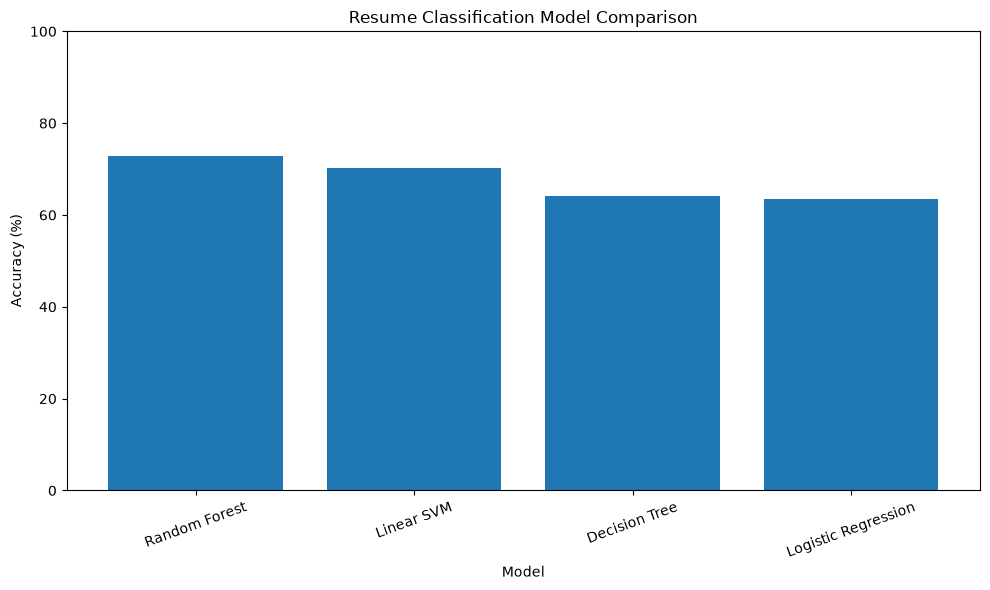

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy (%)"]
)

plt.title(
    "Resume Classification Model Comparison"
)

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=20
)

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

In [21]:
accuracy_dict = {

    "Logistic Regression":
        lr_accuracy,

    "Linear SVM":
        svm_accuracy,

    "Decision Tree":
        dt_accuracy,

    "Random Forest":
        rf_accuracy
}

best_model_name = max(
    accuracy_dict,
    key=accuracy_dict.get
)

best_accuracy = accuracy_dict[
    best_model_name
]

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    round(
        best_accuracy * 100,
        2
    ),
    "%"
)

Best Model: Random Forest
Best Accuracy: 72.84 %


In [35]:
sample_resume = """
John is a Computer Science Engineering graduate with strong
programming skills in Python, Java, C++, and SQL.

He has knowledge of Machine Learning, Artificial Intelligence,
Data Science, Natural Language Processing, and Deep Learning.

He has worked with Pandas, NumPy, Scikit-learn, TensorFlow,
Matplotlib, and Streamlit.

Projects include a Machine Learning-based House Price Prediction
System, Resume Classification System, and an NLP-based Chatbot.

He is interested in Software Engineering, Machine Learning,
Artificial Intelligence, and Data Science roles.
"""

In [36]:
cleaned_resume = clean_resume(sample_resume)

sample_vector = tfidf.transform([cleaned_resume])

prediction = best_model.predict(sample_vector)

print("Predicted Job Category:", prediction[0])

Predicted Job Category: ENGINEERING
